In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image = Image.open("../datasets/916B4425-EDC2-44DD-BDE3-F9E6A9A2114F_1_105_c.jpeg")

In [2]:
img = np.array(image)
img
print(img.shape)

(860, 914, 3)


In [3]:
grid1 = np.ones((3, 4))
grid2 = np.ones((3, 3))
print(grid1)
print()
print(grid2)
print()
print(grid1.shape)
print(grid2.shape)


[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]

[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]

(3, 4)
(3, 3)


In [4]:
#In the above example dot product is not possible because the shape of grid1 is (3, 4) and the shape of grid2 is (3, 3). Hence do perform the dotproduct here I will transpose the first grid
transposeGrid1 = grid1.T
#now lets perform the dot product. Note here @ symbol repersents the dot product 
print(transposeGrid1 @ grid2)

[[3. 3. 3.]
 [3. 3. 3.]
 [3. 3. 3.]
 [3. 3. 3.]]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
np.random.seed(42)
hours_studied = np.random.uniform(1, 10, 50)
noise = np.random.normal(0, 5, 50)


In [7]:
exam_score = hours_studied * 8 + 20 + noise # here we are following the formula of y = mX + C + noise
exam_score = np.clip(exam_score, 0, 100)


In [8]:
data = pd.DataFrame({"hours_studied": hours_studied, "exam_score": exam_score})

data.head()

,hours_studied,exam_score
0,4.370861,58.659221
1,9.556429,97.308271
2,7.587945,80.125322
3,6.387926,69.597892
4,2.404168,31.840732


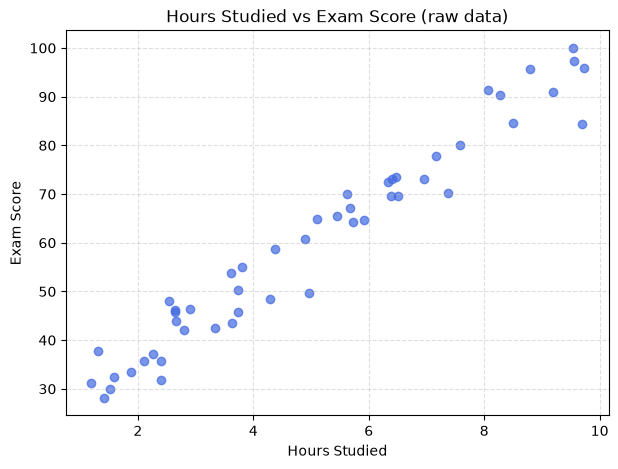

In [9]:
# Now lets plot the data on a graph

plt.figure(figsize=(7, 5))
plt.scatter(data["hours_studied"], data["exam_score"], color = "royalblue", alpha=0.7)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score (raw data)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [10]:
# X must be in 2D for sciket-learn, hence the double brackets [[]]
X = data[["hours_studied"]]
y = data["exam_score"]
# Now Split the data in training and testing data considering 80% training data and 20% testing data. Random_state makes the split reproducible.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)
print(f"Training examples: {len(X_train)}")
print(f"Testing examples: {len(X_test)}")

Training examples: 40
Testing examples: 10


In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7.78]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['hours_studied']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,20.99
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [12]:
w = model.coef_[0]
b = model.intercept_

In [13]:
print(f"Learned weight (w / slope): {w:.2f}")
print(f"Learned bias (b / intercept): {b:.2f}")
print(f"Learned rule: exam_score ~ {w:.2f} * hours_studied + {b:.2f}")

Learned weight (w / slope): 7.78
Learned bias (b / intercept): 20.99
Learned rule: exam_score ~ 7.78 * hours_studied + 20.99


In [14]:
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    "hours_studied": X_test["hours_studied"].values,
    "actual_score": y_test.values,
    "predicted_score": y_pred
})
comparison.round(2)

,hours_studied,actual_score,predicted_score
0,2.91,46.35,43.65
1,4.96,49.75,59.60
2,6.47,73.55,71.33
3,6.96,73.19,75.18
4,5.72,64.24,65.53
5,5.92,64.71,67.07
6,2.80,42.02,42.76
7,8.07,91.31,83.77
8,1.59,32.50,33.33
9,3.62,53.85,49.17


In [15]:
mse = mean_squared_error(y_test, y_pred)

In [16]:
mse

20.039757962226172

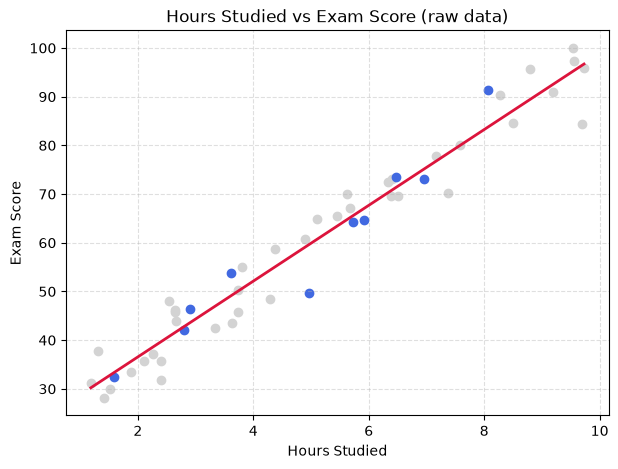

In [17]:
plt.figure(figsize=(7, 5))
plt.scatter(X_train, y_train, color = "lightgray", label="Training data")
plt.scatter(X_test, y_test, color = "royalblue", label="Training data")
# Draw the linerned line across the full range of hours
x_line = np.linspace(X["hours_studied"].min(), X["hours_studied"].max(), 100).reshape(-1,1)
y_line = model.predict(pd.DataFrame(x_line, columns=["hours_studied"]))
plt.plot(x_line, y_line, color="crimson", linewidth=2, label="Learned model (line)")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score (raw data)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()